# Setup

In [ ]:
import torch
import plotly
import pandas as pd
import numpy as np
from tqdm import tqdm
from torch.nn import CosineSimilarity

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

sm = torch.nn.Softmax(dim=0)

LANGS = ["rus", "ger", "eng", "ned", "zho", "ita", "vie"]
# LANGS = ["rus", "zho", "tur", "jap"]
SRC_LANG = "fre"
# LANGS = ["ger", "fre", "pol"]

# MODEL = "mGPT"
# layer, head = (11, 2)
# MODEL = "aya-expanse-8b"
# layer, head = (15, 0)
# MODEL = "Meta-Llama-3-8B"
# layer, head = (14, 25)

MODEL2HEAD = {
    "mGPT": (11, 2),
    # "mGPT": (11, 7),
    "aya-expanse-8b": (15, 0),
    "Meta-Llama-3-8B": (14, 25)
}

EXPERIMENT = "noun-adj-complete"
# EXPERIMENT = "svo"

palette = "plasma"

path_format = '/Users/fixed/Desktop/saar/thesis/word-order-thesis/output/steer/probs/{EXPERIMENT}_{MODEL}_{SRC_LANG}-{tgt_lang_base}_{SRC_LANG}-{tgt_lang_plant}_layer{layer}_head{head}.csv'

## Calculate KL divergence

In [7]:
def get_kl_divergences(df, token_types=[]):
    """
    Calculate KL divergence between probability distributions for each sentence_id.
    
    For each sentence_id, we have a probability distribution over tokens (noun-fre, adj-fre, etc.).
    We calculate KL(plant_dist || base_dist) for each sentence.
    """
    kl_divergences = []
    
    for sentence_id in df['sentence_id'].unique():
        sentence_data = df[df['sentence_id'] == sentence_id]

        # If token_types is specified, filter the sentence_data to include only those token types
        if token_types:
            sentence_data = sentence_data[sentence_data['token_type'].isin(token_types)]
        
        # Normalize probabilities to ensure they sum to 1
        values_base = torch.tensor(sentence_data['prob_base'].values)
        values_plant = torch.tensor(sentence_data['prob_plant'].values)
        prob_base = values_base / values_base.sum()
        prob_plant = values_plant / values_plant.sum()

        # print("VALUES:", sentence_data[['token', 'prob_base', 'prob_plant']])
        # print("PROBABILITY BASE:", list(prob_base))
        # print("PROBABILITY PLANT:", list(prob_plant))
        # print()

        # Calculate KL divergence: sum of prob_plant * log(prob_plant / prob_base)
        kl = (prob_plant * torch.log(prob_plant / prob_base)).sum()

        kl_divergences.append({'sentence_id': sentence_id, 'kl_divergence': kl})
    
    result = pd.DataFrame(kl_divergences)
    return result

In [8]:
def get_kl_grid(lang_same=True, src_lang="eng", s_pair=("noun", "adj"), model="", layer=0, head=0):
    kl_div_grid = np.zeros((len(LANGS), len(LANGS)))
    
    for i, tgt_lang_base in enumerate(LANGS):
        for j, tgt_lang_plant in enumerate(LANGS):
            if tgt_lang_base == tgt_lang_plant:
                continue
            tag1 = ""
            tag2 = ""
            tag1 += s_pair[0]+"-"
            tag2 += s_pair[1]+"-"
            tag1 += tgt_lang_base
            if lang_same:
                tag2 += tgt_lang_base
            else:
                tag2 += tgt_lang_plant
            # print(path_format)
            # print(path_format.format(EXPERIMENT=EXPERIMENT, MODEL=model, SRC_LANG=SRC_LANG, tgt_lang_base=tgt_lang_base, tgt_lang_plant=tgt_lang_plant, layer=layer, head=head))
            data = pd.read_csv(path_format.format(EXPERIMENT=EXPERIMENT, MODEL=model, SRC_LANG=src_lang, tgt_lang_base=tgt_lang_base, tgt_lang_plant=tgt_lang_plant, layer=layer, head=head))
            df = pd.DataFrame(data)
            result = get_kl_divergences(df, token_types=[tag1, tag2])['kl_divergence'].mean()
            # if type == "part_of_speech_noun_adj":
            #     result = get_kl_divergences(df, token_types=[f'noun-{tgt_lang_base}', f'adj-{tgt_lang_base}'])['kl_divergence'].mean()
            # elif type == "part_of_speech_modal_verb":
            #     result = get_kl_divergences(df, token_types=[f'modal-{tgt_lang_base}', f'verb-{tgt_lang_base}'])['kl_divergence'].mean()
            # elif type == "language_noun":
            #     result = get_kl_divergences(df, token_types=[f'noun-{tgt_lang_base}', f'noun-{tgt_lang_plant}'])['kl_divergence'].mean()
            # elif type == "language_adj":
            #     result = get_kl_divergences(df, token_types=[f'adj-{tgt_lang_base}', f'adj-{tgt_lang_plant}'])['kl_divergence'].mean()
            # elif type == "language_modal":
            #     result = get_kl_divergences(df, token_types=[f'modal-{tgt_lang_base}', f'modal-{tgt_lang_plant}'])['kl_divergence'].mean()
            # elif type == "language_verb":
            #     result = get_kl_divergences(df, token_types=[f'verb-{tgt_lang_base}', f'verb-{tgt_lang_plant}'])['kl_divergence'].mean()
            kl_div_grid[i, j] = result
    
    return kl_div_grid

def plot_kl_grid(kl_div_grid, title):
    fig, ax = plt.subplots()
    im = ax.imshow(np.array(kl_div_grid.tolist()))

    ax.set_xticks(range(len(LANGS)), labels=LANGS,
                  rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticks(range(len(LANGS)), labels=LANGS)
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    return fig, ax

In [17]:
kl_div_grid_pos = get_kl_grid(lang_same=True, s_pair=("noun", "adj"))
fig_pos, ax_pos = plot_kl_grid(kl_div_grid_pos, title="KL Divergence for Nouns and Adjectives")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/fixed/Desktop/saar/thesis/word-order-thesis/output/steer/probs/noun-adj-complete__eng-rus_eng-ger_layer0_head0.csv'

In [9]:
# Compute all three types with the same color scale
# types = [(True, ("verb", "object")), (False, ("verb", "verb")), (False, ("object", "object"))]
types = [(True, ("noun", "adj")), (False, ("noun", "noun")), (False, ("adj", "adj"))]
grids_eng = {model: {} for model in MODEL2HEAD.keys()}

for model in tqdm(MODEL2HEAD.keys()):
    for lang_same, s_pair in tqdm(types):
        grids_eng[model][(lang_same, s_pair)] = get_kl_grid(lang_same=lang_same, src_lang=SRC_LANG, s_pair=s_pair, model=model, layer=MODEL2HEAD[model][0], head=MODEL2HEAD[model][1])
        # grids_eng[model][(lang_same, s_pair)][(layer, head)] = get_kl_grid(lang_same=lang_same, s_pair=s_pair, model=model, layer=layer, head=head)

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [02:28<00:00, 49.48s/it]


In [ ]:
SRC_LANG = "fre"
LANGS = ["rus", "ger", "eng", "ned", "zho", "ita", "vie"]

# Compute all three types with the same color scale
# types = [(True, ("verb", "object")), (False, ("verb", "verb")), (False, ("object", "object"))]
types = [(True, ("noun", "adj")), (False, ("noun", "noun")), (False, ("adj", "adj"))]
grids_fre = {model: {} for model in MODEL2HEAD.keys()}

for model in tqdm(MODEL2HEAD.keys()):
    for lang_same, s_pair in tqdm(types):
        grids_fre[model][(lang_same, s_pair)] = get_kl_grid(lang_same=lang_same, src_lang=SRC_LANG, s_pair=s_pair, model=model, layer=MODEL2HEAD[model][0], head=MODEL2HEAD[model][1])
        # grids_eng[model][(lang_same, s_pair)][(layer, head)] = get_kl_grid(lang_same=lang_same, s_pair=s_pair, model=model, layer=layer, head=head)

In [11]:
titles = ["Base vs. Plant Part of Speech", "Noun in Base vs. Plant Language", "Adjective in Base vs. Plant Language"]

fig = make_subplots(rows=3, cols=3, subplot_titles=titles)

# MODEL2HEAD = {
#     "mGPT": (11, 2),
#     "mGPT2": (11, 7),
#     "aya-expanse-8b": (15, 0),
#     "Meta-Llama-3-8B": (14, 25)
# }
# color_scales = ["plasma", "Plotly3", "viridis"]

grids = grids_eng

for idx_model, (model_name, heads) in enumerate(MODEL2HEAD.items()):
    vmin = min(grid.min() for grid in grids[model_name].values() if not np.isnan(grid).all())
    vmax = max(grid.max() for grid in grids[model_name].values() if not np.isnan(grid).all())
    for idx_type, (type_name, title) in enumerate(zip(types, titles)):
        grid = grids[model_name][type_name]
        row = idx_model + 1
        col = idx_type + 1

        # Build annotation text
        text_annotations = [["%.2f" % grid[i, j] for j in range(len(LANGS))] for i in range(len(LANGS))]

        fig.add_trace(go.Heatmap(
            z=grid,
            x=LANGS,
            y=LANGS,
            zmin=vmin,
            zmax=vmax,
            # colorscale=color_scales[idx_model],
            colorscale="plasma",
            # text=text_annotations,
            # texttemplate="%{text}",
            textfont=dict(size=8, color="white"),
            showscale=(row == 1 and col == len(types)),  # only show colorbar on last subplot
            colorbar=dict(
                title='KL div',
                thickness=15,  # width of the colorbar in pixels
                len=0.3,       # length as a fraction of the plot height
            ),
        ), row=row, col=col)

        # Reverse y-axis to match imshow orientation (origin at top-left)
        fig.update_yaxes(autorange='reversed', row=row, col=col)
        fig.update_xaxes(tickangle=45, row=row, col=col)

    fig.update_layout(
        width=1200,
        height=450*len(MODEL2HEAD.keys()),
        title_text=f"KL Divergence for NP dataset: most S-sensitive attention heads",
    )
for idx_model, model_name in enumerate(MODEL2HEAD.keys()):
    # get the y domain of the first col in this row
    axis_key = f"yaxis{idx_model * len(types) + 1 if idx_model > 0 else ''}"
    domain = fig.layout[axis_key].domain
    y_center = (domain[0] + domain[1]) / 2

    fig.add_annotation(
        text=model_name,
        x=-0.05,
        y=y_center,
        xref="paper",
        yref="paper",
        showarrow=False,
        textangle=-90,
        font=dict(size=14),
        xanchor="right",
    )
fig.show()
plotly.offline.plot(fig, filename=f"/Users/fixed/Desktop/saar/thesis/word-order-thesis/output/steer/figures/kl_{EXPERIMENT}_{SRC_LANG}.html", auto_open=False, include_plotlyjs=True)

'/Users/fixed/Desktop/saar/thesis/word-order-thesis/output/steer/figures/kl_noun-adj-complete_eng.html'

In [73]:
# Example usage: load your CSV file and calculate mean KL divergence
# df = pd.read_csv('your_data.csv')
# mean_kl = get_kl_divergence(df)
# print(mean_kl)

# tgt_lang_base = "zho"

kl_div_grid = torch.zeros([len(LANGS), len(LANGS)])

# Or with the provided example data:
for i, tgt_lang_base in enumerate(LANGS):
    for j, tgt_lang_plant in enumerate(LANGS):
        if tgt_lang_base == tgt_lang_plant:
            continue
        data = pd.read_csv(f'/Users/fixed/Desktop/saar/thesis/word-order-thesis/output/steer/probs/{EXPERIMENT}_{MODEL}_eng-{tgt_lang_base}_eng-{tgt_lang_plant}_layer{layer}_head{head}.csv')
        df = pd.DataFrame(data)
        result = get_kl_divergences(df, token_types=[f'noun-{tgt_lang_base}', f'adj-{tgt_lang_base}'])['kl_divergence'].mean()
        kl_div_grid[i, j] = result

In [71]:
kl_div_grid = torch.zeros([len(LANGS), len(LANGS)])

# Or with the provided example data:
for i, tgt_lang_base in enumerate(LANGS):
    for j, tgt_lang_plant in enumerate(LANGS):
        if tgt_lang_base == tgt_lang_plant:
            continue
        data = pd.read_csv(f'/Users/fixed/Desktop/saar/thesis/word-order-thesis/output/steer/probs/{EXPERIMENT}_{MODEL}_eng-{tgt_lang_base}_eng-{tgt_lang_plant}_layer{layer}_head{head}.csv')
        df = pd.DataFrame(data)
        result = get_kl_divergences(df, token_types=[f'adj-{tgt_lang_base}', f'adj-{tgt_lang_plant}'])['kl_divergence'].mean()
        kl_div_grid[i, j] = result

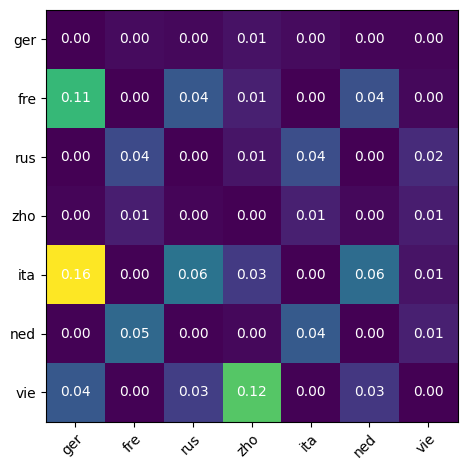

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=3)
im = ax.imshow(np.array(kl_div_grid.tolist()))

ax.set_xticks(range(len(LANGS)), labels=LANGS,
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(LANGS)), labels=LANGS)

# Loop over data dimensions and create text annotations.
for i in range(len(LANGS)):
    for j in range(len(LANGS)):
        text = ax.text(j, i, "%.2f" % kl_div_grid[i, j].item(),
                       ha="center", va="center", color="w")

fig.tight_layout()
plt.show()

In [5]:
data.head()

,Unnamed: 0,sentence_id,token_type,token,prob_base,prob_plant,type
0,0,0,adj-vie,tr,0.070464,0.926508,head_attention_value_output
1,1,0,noun-vie,d,0.929536,0.073491,head_attention_value_output
2,2,1,adj-vie,to,0.001398,0.829230,head_attention_value_output
3,3,1,noun-vie,chu,0.998601,0.170770,head_attention_value_output
4,4,2,adj-vie,tr,0.500000,0.500000,head_attention_value_output


## Plot activations

In [163]:
lang2mean_activation = {model: {} for model in MODEL2HEAD.keys()}

for model in MODEL2HEAD.keys():
    for lang in LANGS:
        act_path = f"/Users/fixed/Desktop/saar/thesis/word-order-thesis/output/activations/noun-adj-complete_{model}_eng-{lang}_layer{MODEL2HEAD[model][0]}_head{MODEL2HEAD[model][1]}.pt"
        lang2mean_activation[model][lang] = torch.load(act_path)

In [165]:
lang2mean_activation.keys()

dict_keys(['mGPT', 'aya-expanse-8b', 'Meta-Llama-3-8B'])

In [155]:
cos_sim = CosineSimilarity(dim=-1)

In [167]:
lang_similarity_grids = {}
for model in MODEL2HEAD.keys():
    lang_similarity_grids[model] = torch.zeros([len(LANGS), len(LANGS)])

    for i, i_lang in enumerate(LANGS):
        for j, j_lang in enumerate(LANGS):
            lang_similarity_grids[model][i, j] = cos_sim(lang2mean_activation[model][i_lang], lang2mean_activation[model][j_lang]).item()

In [ ]:
upper_mask = np.tri(lang_similarity_grid.shape[0], lang_similarity_grid.shape[1], k=-1).T

In [170]:
for model in MODEL2HEAD.keys():
    lang_similarity_grids[model] = np.ma.array(lang_similarity_grids[model], mask=upper_mask)

<Figure size 2000x1600 with 0 Axes>

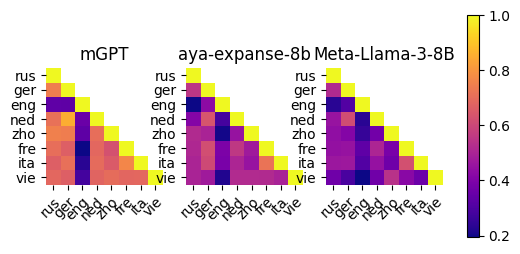

In [183]:
from matplotlib.pyplot import figure
figure(figsize=(25, 20), dpi=80)

fig, axs = plt.subplots(nrows=1, ncols=3)
for i, model in enumerate(MODEL2HEAD.keys()):
    ax = axs[i]
    im = ax.imshow(lang_similarity_grids[model], interpolation='nearest', cmap='plasma')
    ax.set_title(model)

    ax.set_xticks(range(len(LANGS)), labels=LANGS,
                rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticks(range(len(LANGS)), labels=LANGS)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Loop over data dimensions and create text annotations.
    # for i in range(len(LANGS)):
    #     for j in range(len(LANGS)):
    #         text = ax.text(j, i, "%.2f" % lang_similarity_grid[i, j].item(),
    #                     ha="center", va="center", color="w")

fig.colorbar(im, ax=axs, shrink=0.6)
# fig.tight_layout()
plt.show()

In [185]:
fig = make_subplots(rows=1, cols=3, subplot_titles=list(MODEL2HEAD.keys()))

for i, model in enumerate(MODEL2HEAD.keys()):
    z = lang_similarity_grids[model].filled(np.nan)  # Fill masked values with NaN for blank upper triangle
    fig.add_trace(go.Heatmap(
        z=z,
        x=LANGS,
        y=LANGS,
        colorscale='plasma',
        showscale=(i == 2),  # only show colorbar on the last subplot
        colorbar=dict(
            title='Cosine Similarity',
            thickness=15,
            len=0.6,
        ) if i == 2 else None,
    ), row=1, col=i+1)

    # Reverse y-axis to match imshow orientation
    fig.update_yaxes(autorange='reversed', row=1, col=i+1)
    fig.update_xaxes(tickangle=45, row=1, col=i+1)

fig.update_layout(
    width=1200,
    height=400,
    title_text="Language Similarity Heatmaps for Different Models",
)
fig.show()
plotly.offline.plot(fig, filename=f"/Users/fixed/Desktop/saar/thesis/word-order-thesis/output/steer/figures/lang_similarity_{EXPERIMENT}.html", auto_open=False, include_plotlyjs=True)

'/Users/fixed/Desktop/saar/thesis/word-order-thesis/output/steer/figures/lang_similarity_svo.html'